# Sizing the Axes of Attention

An expression is written with symbolic axis sizes, so one expression stands for
every model of that shape. A configuration collects the free symbols of an
expression and assigns an integer to the ones it is asked about. This notebook
builds attention, lists its free symbols, gives the head dimension a size and
draws the sized expression.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Operators as ops
import display.display_config as display_config
import term_utilities.generate_config as generate_config

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=700)

## The expression

Two contractions with a softmax between them. `d` is the head dimension the
scores sum over, `q` the queries and `x` the keys.

Attention with every axis size still symbolic.


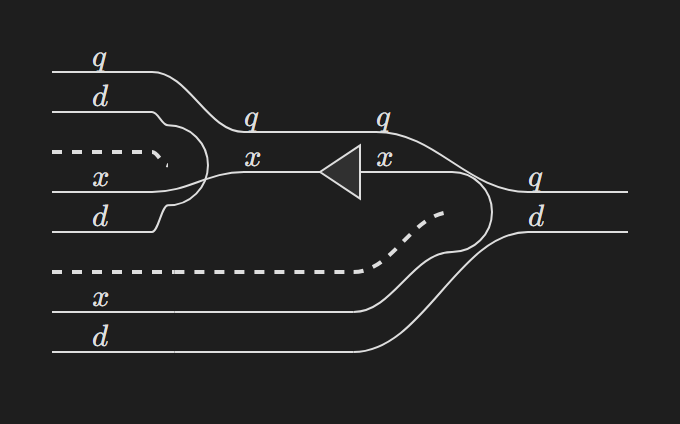

In [2]:
attention = (ops.Einops.template('q d, x d -> q x')
             @ ops.SoftMax.template()
             @ ops.Einops.template('q x, x d -> q d'))

await notebook_diagrams.show_diagram(
    attention, 'Attention with every axis size still symbolic.', settings=DIAGRAMS)

## The configuration

`generate_config.NumericConfig.template` walks the expression and records every
`FreeNumeric` it holds, which is every axis size nothing has fixed.
`display_config.display_config` prints the table of them, with the bucket and
the value of each one that has been assigned.

Assigning `d` puts every symbol whose name reads `d` into one bucket and gives
that bucket an integer. `apply_context` rewrites the expression with the
assignment in place, so a configuration taken of the result finds `d` gone and
the two sequence lengths still free.

Name|Type       |Bucket  |Assignment
d   |FreeNumeric|        |          
q   |FreeNumeric|        |          
x   |FreeNumeric|        |          
d   |FreeNumeric|        |          
Name|Type       |Bucket  |Assignment         
d   |FreeNumeric|0       |Integer(_value=128)
q   |FreeNumeric|        |                   
x   |FreeNumeric|        |                   
d   |FreeNumeric|0       |Integer(_value=128)
Name|Type       |Bucket  |Assignment
q   |FreeNumeric|        |          
x   |FreeNumeric|        |          
The same expression with the head dimension sized at 128. The wire label carries the integer in place of the symbol.


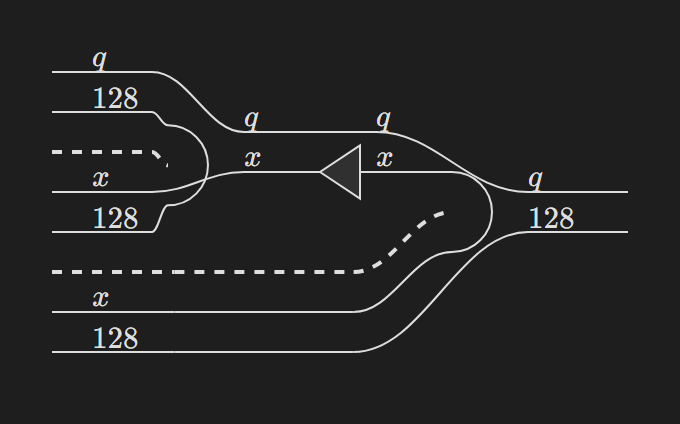

In [3]:
config = generate_config.NumericConfig.template(attention)
print(display_config.display_config(config))

assert config.search('d'), 'the head dimension is a free symbol of the expression'

config.assign_value('d', 128)
print(display_config.display_config(config))
attention_128 = config.apply_context(attention)

after = generate_config.NumericConfig.template(attention_128)
print(display_config.display_config(after))

assert not after.search('d'), 'the assigned head dimension is no longer free'
assert {term.uid._name.body for term in after.terms} == {'q', 'x'}, (
    'the two sequence lengths are the symbols that remain free'
)
await notebook_diagrams.show_diagram(
    attention_128,
    'The same expression with the head dimension sized at 128. The wire label '
    'carries the integer in place of the symbol.',
    settings=DIAGRAMS)